# Phase 2: Statistical Insight & Clinical Profiling

## Project: Advanced Health Analytics & Readmission Prediction

In this phase, we analyze the cleaned clinical dataset to identify key drivers of hospital readmissions. We focus on demographic distributions, categorical associations, and difference-in-means testing.

### Objectives:
1. **Population Demographics**: Profiling age and gender distributions.
2. **Category Association (Chi-Square)**: Testing if comorbidities (Diabetes, Hypertension) are statistically linked to readmission.
3. **Difference Testing (ANOVA/T-Test)**: Analyzing numerical factors like Stay Duration.
4. **Clinical Segmentation**: Identifying high-risk patient subgroups.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

### 1. Load Processed Data
We start with the data that underwent cleansing in the previous notebook. For this exercise, we will re-apply the cleaning logic to maintain a standalone flow.

In [7]:
data_path = "../data/raw/synthetic_clinical_data.csv"
df = pd.read_csv(data_path)

# Quick clean (Same as Phase 1)
df_clean = df.dropna(subset=['Admission_Date']).copy()
df_clean['Hemoglobin_gdL'] = df_clean['Hemoglobin_gdL'].fillna(df_clean['Hemoglobin_gdL'].median())
df_clean['Systolic_BP'] = df_clean['Systolic_BP'].clip(60, 220)
df_clean['Glucose_mgdL'] = df_clean['Glucose_mgdL'].clip(40, 400)

print(f"Ready for analysis: {df_clean.shape[0]} records.")

Ready for analysis: 11880 records.


### 2. Demographic Analysis
Understanding who our patients are. We look at age distribution and gender ratios.

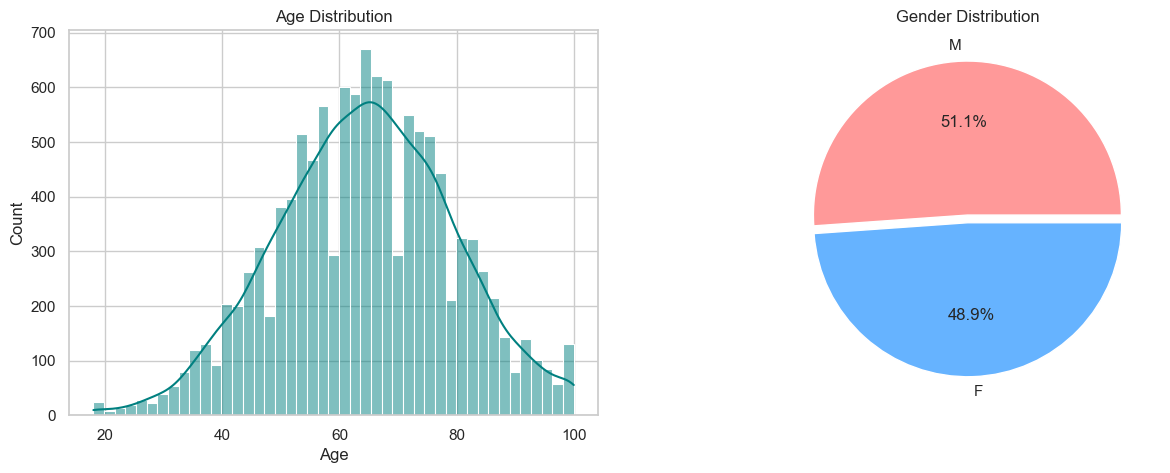

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_clean['Age'], kde=True, ax=ax[0], color='teal')
ax[0].set_title('Age Distribution')

df_clean['Gender'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], colors=['#ff9999','#66b3ff'], explode=(0.05, 0))
ax[1].set_title('Gender Distribution')

plt.show()

### 3. Categorical Significance: Chi-Square Test
Does having **Diabetes** increase the likelihood of **Readmission**? We use a Chi-Square test of independence.

### Chi-Square Analysis: Diabetes vs. Readmission
Chi2 Statistic: 392.8149
P-value: 2.0187e-87

RESULT: Statistically Significant association found between Diabetes and Readmission.


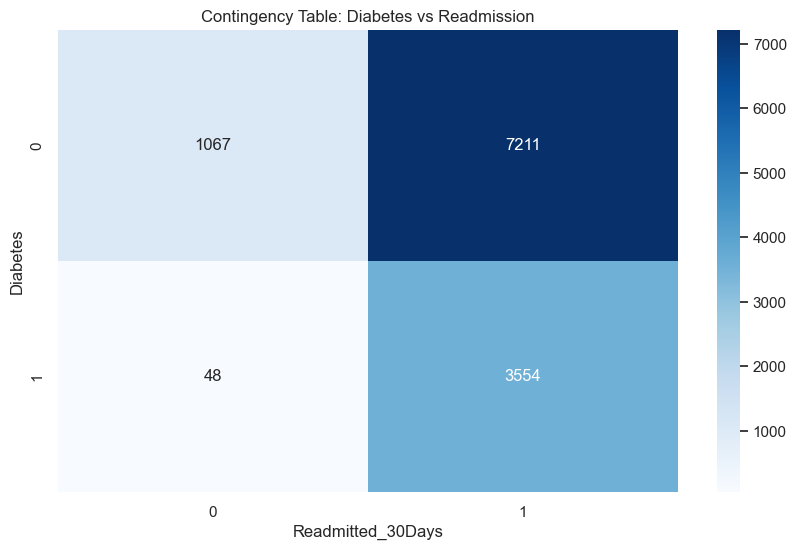

In [9]:
# Contingency Table
contingency = pd.crosstab(df_clean['Diabetes'], df_clean['Readmitted_30Days'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("### Chi-Square Analysis: Diabetes vs. Readmission")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("\nRESULT: Statistically Significant association found between Diabetes and Readmission.")
else:
    print("\nRESULT: No significant association found.")

sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')
plt.title('Contingency Table: Diabetes vs Readmission')
plt.show()

### 4. Continuous Factor Analysis: T-Test
Do readmitted patients have significantly longer initial hospital stays?

### T-Test Analysis: Stay Duration vs. Readmission
T-Statistic: 20.8289
P-value: 1.1525e-94


/var/folders/y6/plfvbl_x6f5g3pv5rs9pcn100000gn/T/ipykernel_18409/4269591884.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Readmitted_30Days', y='Stay_Duration_Days', data=df_clean, palette='Set2')


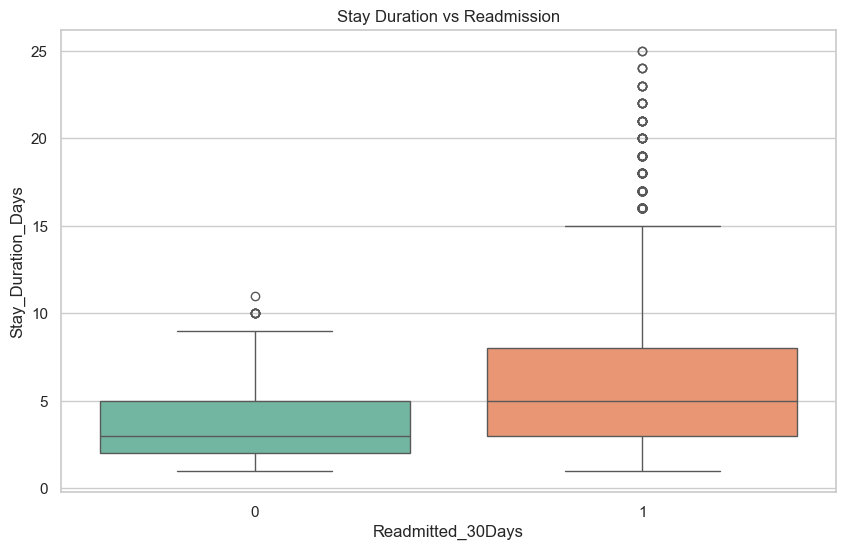

In [10]:
readmitted = df_clean[df_clean['Readmitted_30Days'] == 1]['Stay_Duration_Days']
not_readmitted = df_clean[df_clean['Readmitted_30Days'] == 0]['Stay_Duration_Days']

t_stat, p_val = stats.ttest_ind(readmitted, not_readmitted)

print("### T-Test Analysis: Stay Duration vs. Readmission")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

sns.boxplot(x='Readmitted_30Days', y='Stay_Duration_Days', data=df_clean, palette='Set2')
plt.title('Stay Duration vs Readmission')
plt.show()